# Pertemuan 13: Pengantar Deep Learning dan NLP Dasar

**Mata Kuliah:** Data Science (200302305)
**Program Studi:** PJJ Informatika, Semester 4
**Dosen Pengampu:** Syahid Abdullah, S.Si, M.Kom

| Keterangan | Isi |
| --- | --- |
| Nama Lengkap | [ISI NAMA LENGKAP ANDA] |
| NIM | [ISI NIM ANDA] |
| Kelas | [ISI KELAS ANDA] |

**Topik:** Konsep Dasar Artificial Neural Network serta Pemrosesan Teks dengan TF-IDF untuk Analisis Sentimen


## 1. Tujuan Praktikum

1. Memahami komponen dasar Artificial Neural Network, yaitu neuron, bobot, bias, dan fungsi aktivasi.
2. Membangun satu neuron dari nol memakai numpy untuk memperlihatkan proses pembelajarannya.
3. Melatih jaringan saraf berlapis memakai `MLPClassifier` dan membandingkannya dengan model klasik.
4. Mengubah teks menjadi angka memakai TF-IDF.
5. Membangun model analisis sentimen sederhana beserta evaluasinya.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print('Pustaka berhasil dimuat.')

Pustaka berhasil dimuat.


# BAGIAN PERTAMA: PENGANTAR DEEP LEARNING

## 2. Konsep Dasar Artificial Neural Network

Artificial Neural Network terinspirasi dari cara kerja jaringan saraf pada makhluk
hidup. Satu neuron buatan bekerja melalui tiga tahap.

**Tahap pertama, penjumlahan berbobot.** Setiap masukan dikalikan bobotnya lalu
dijumlahkan bersama bias, ditulis sebagai z = w1 x1 + w2 x2 + ... + b.

**Tahap kedua, fungsi aktivasi.** Nilai z dilewatkan ke fungsi tak linear agar jaringan
mampu memodelkan hubungan yang tidak berbentuk garis lurus. Contoh yang umum adalah
sigmoid dan ReLU.

**Tahap ketiga, pembelajaran.** Selisih antara keluaran dan nilai sebenarnya diukur
memakai fungsi kerugian, kemudian bobot diperbarui berlawanan arah gradien melalui
proses backpropagation.

Tanpa fungsi aktivasi tak linear, berapa pun lapisan yang ditumpuk hasilnya tetap
setara dengan satu model linear tunggal.

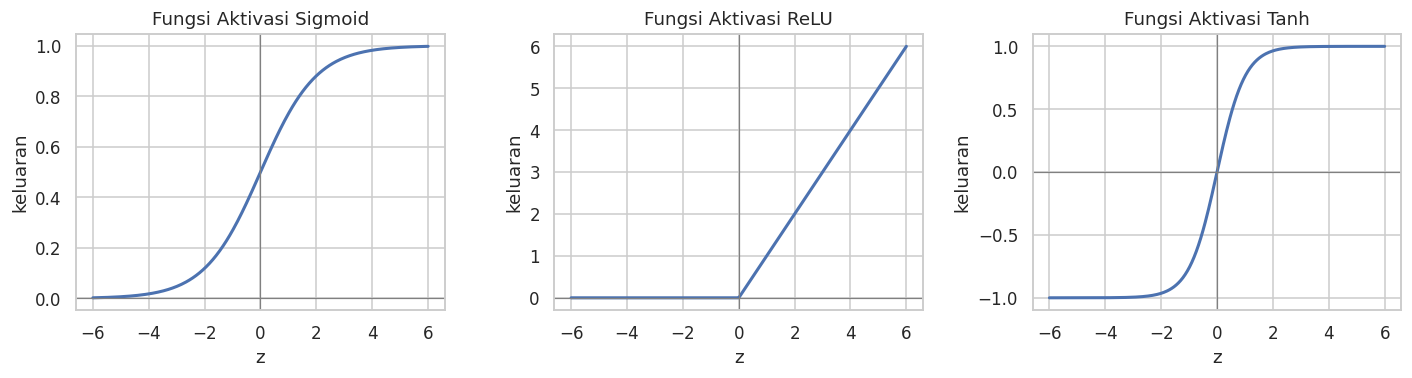

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


def relu(z):
    return np.maximum(0, z)


def tanh(z):
    return np.tanh(z)


z = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (nama, fungsi) in zip(axes, [('Sigmoid', sigmoid), ('ReLU', relu), ('Tanh', tanh)]):
    ax.plot(z, fungsi(z), linewidth=2, color='#4c72b0')
    ax.axhline(0, color='grey', linewidth=0.8)
    ax.axvline(0, color='grey', linewidth=0.8)
    ax.set_title(f'Fungsi Aktivasi {nama}')
    ax.set_xlabel('z')
    ax.set_ylabel('keluaran')

plt.tight_layout()
plt.show()

## 3. Membangun Satu Neuron dari Nol

Neuron berikut dilatih untuk mempelajari gerbang logika AND. Seluruh proses ditulis
manual memakai numpy agar terlihat bagaimana bobot berubah pada setiap iterasi.

In [3]:
class NeuronSederhana:
    """Satu neuron dengan aktivasi sigmoid yang dilatih memakai gradient descent."""

    def __init__(self, jumlah_masukan, laju_belajar=0.5, seed=42):
        acak = np.random.default_rng(seed)
        self.bobot = acak.normal(0, 0.5, jumlah_masukan)
        self.bias = 0.0
        self.laju_belajar = laju_belajar
        self.riwayat_kerugian = []

    def maju(self, X):
        """Forward pass: hitung keluaran neuron."""
        return sigmoid(X @ self.bobot + self.bias)

    def latih(self, X, y, epoch=2000):
        n = len(y)
        for _ in range(epoch):
            keluaran = self.maju(X)
            # Binary cross entropy sebagai fungsi kerugian
            kerugian = -np.mean(y * np.log(keluaran + 1e-9) + (1 - y) * np.log(1 - keluaran + 1e-9))
            self.riwayat_kerugian.append(kerugian)

            # Backpropagation: turunan kerugian terhadap bobot dan bias
            galat = keluaran - y
            gradien_bobot = (X.T @ galat) / n
            gradien_bias = np.mean(galat)

            self.bobot -= self.laju_belajar * gradien_bobot
            self.bias -= self.laju_belajar * gradien_bias
        return self

    def prediksi(self, X):
        return (self.maju(X) >= 0.5).astype(int)


X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_and = np.array([0, 0, 0, 1], dtype=float)

neuron = NeuronSederhana(jumlah_masukan=2, laju_belajar=0.5, seed=RANDOM_STATE)
neuron.latih(X_and, y_and, epoch=3000)

print('Bobot akhir:', np.round(neuron.bobot, 4))
print('Bias akhir :', round(float(neuron.bias), 4))
print()
print('Pengujian gerbang AND')
print('x1  x2  | peluang | prediksi | target')
for masukan, target in zip(X_and, y_and):
    peluang = neuron.maju(masukan)
    print(f'{int(masukan[0])}   {int(masukan[1])}   |  {peluang:.4f} |    {int(peluang >= 0.5)}     |   {int(target)}')

Bobot akhir: [8.2344 8.2344]
Bias akhir : -12.5227

Pengujian gerbang AND
x1  x2  | peluang | prediksi | target
0   0   |  0.0000 |    0     |   0
0   1   |  0.0135 |    0     |   0
1   0   |  0.0135 |    0     |   0
1   1   |  0.9810 |    1     |   1


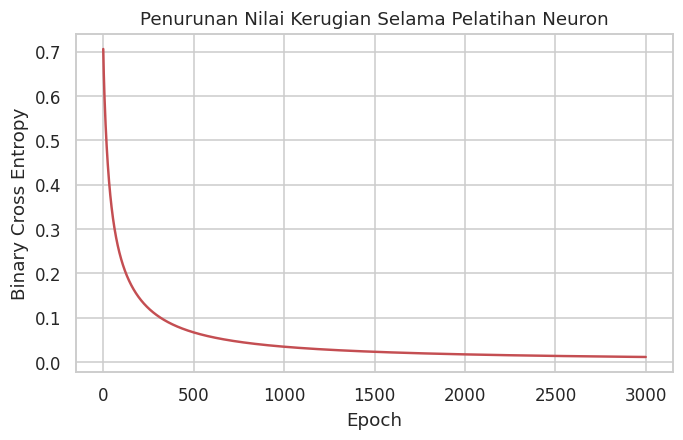

Kerugian awal  : 0.7064
Kerugian akhir : 0.0116


In [4]:
plt.figure(figsize=(7, 4))
plt.plot(neuron.riwayat_kerugian, color='#c44e52', linewidth=1.6)
plt.title('Penurunan Nilai Kerugian Selama Pelatihan Neuron')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross Entropy')
plt.show()

print(f'Kerugian awal  : {neuron.riwayat_kerugian[0]:.4f}')
print(f'Kerugian akhir : {neuron.riwayat_kerugian[-1]:.4f}')

## 4. Keterbatasan Satu Neuron

Satu neuron hanya mampu memisahkan data memakai satu garis lurus. Gerbang logika XOR
tidak dapat dipisahkan dengan cara itu, sehingga satu neuron pasti gagal mempelajarinya.
Inilah alasan lapisan tersembunyi diperlukan, dan inilah pula yang menjadi dasar
lahirnya deep learning.

In [5]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

neuron_xor = NeuronSederhana(jumlah_masukan=2, laju_belajar=0.5, seed=RANDOM_STATE)
neuron_xor.latih(X_xor, y_xor, epoch=3000)

print('Satu neuron mencoba mempelajari XOR')
print('x1  x2  | peluang | prediksi | target')
for masukan, target in zip(X_xor, y_xor):
    peluang = neuron_xor.maju(masukan)
    print(f'{int(masukan[0])}   {int(masukan[1])}   |  {peluang:.4f} |    {int(peluang >= 0.5)}     |   {int(target)}')

akurasi_satu = (neuron_xor.prediksi(X_xor) == y_xor).mean()
print(f'\nAkurasi satu neuron pada XOR: {akurasi_satu:.2f}')

Satu neuron mencoba mempelajari XOR
x1  x2  | peluang | prediksi | target
0   0   |  0.5000 |    1     |   0
0   1   |  0.5000 |    1     |   1
1   0   |  0.5000 |    1     |   1
1   1   |  0.5000 |    1     |   0

Akurasi satu neuron pada XOR: 0.50


In [6]:
# Jaringan dengan satu lapisan tersembunyi mampu menyelesaikan XOR
mlp_xor = MLPClassifier(hidden_layer_sizes=(4,), activation='tanh', solver='lbfgs',
                        max_iter=5000, random_state=RANDOM_STATE)
mlp_xor.fit(X_xor, y_xor)

print('Jaringan berlapis mempelajari XOR')
print('x1  x2  | prediksi | target')
for masukan, target in zip(X_xor, y_xor):
    pred = mlp_xor.predict(masukan.reshape(1, -1))[0]
    print(f'{int(masukan[0])}   {int(masukan[1])}   |    {int(pred)}     |   {int(target)}')

print(f'\nAkurasi jaringan berlapis pada XOR: {mlp_xor.score(X_xor, y_xor):.2f}')

Jaringan berlapis mempelajari XOR
x1  x2  | prediksi | target
0   0   |    0     |   0
0   1   |    1     |   1
1   0   |    1     |   1
1   1   |    0     |   0

Akurasi jaringan berlapis pada XOR: 1.00


## 5. Multi Layer Perceptron pada Data Tak Linear

Dataset `make_moons` berbentuk dua bulan sabit yang saling mengait sehingga tidak dapat
dipisahkan oleh satu garis lurus. Dataset ini dipakai untuk membandingkan Logistic
Regression dengan jaringan saraf berlapis.

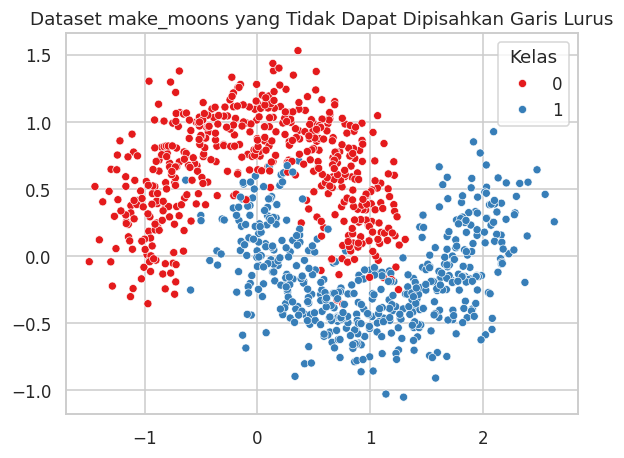

In [7]:
X_moon, y_moon = make_moons(n_samples=1000, noise=0.22, random_state=RANDOM_STATE)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_moon, y_moon, test_size=0.25, random_state=RANDOM_STATE, stratify=y_moon
)

penskala = StandardScaler()
X_tr_s = penskala.fit_transform(X_tr)
X_te_s = penskala.transform(X_te)

plt.figure(figsize=(6, 4.5))
sns.scatterplot(x=X_moon[:, 0], y=X_moon[:, 1], hue=y_moon, palette='Set1', s=28)
plt.title('Dataset make_moons yang Tidak Dapat Dipisahkan Garis Lurus')
plt.legend(title='Kelas')
plt.show()

In [8]:
logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg.fit(X_tr_s, y_tr)

mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    alpha=1e-3,
    learning_rate_init=0.01,
    max_iter=800,
    random_state=RANDOM_STATE
)
mlp.fit(X_tr_s, y_tr)

pred_logreg = logreg.predict(X_te_s)
pred_mlp = mlp.predict(X_te_s)

banding = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_score(y_te, pred_logreg),
        'Precision': precision_score(y_te, pred_logreg),
        'Recall': recall_score(y_te, pred_logreg),
        'F1-Score': f1_score(y_te, pred_logreg),
    },
    {
        'Model': 'Neural Network (32, 16)',
        'Accuracy': accuracy_score(y_te, pred_mlp),
        'Precision': precision_score(y_te, pred_mlp),
        'Recall': recall_score(y_te, pred_mlp),
        'F1-Score': f1_score(y_te, pred_mlp),
    },
]).set_index('Model').round(4)

print('Arsitektur jaringan:', [c.shape for c in mlp.coefs_])
print('Jumlah iterasi sampai berhenti:', mlp.n_iter_)
print()
banding

Arsitektur jaringan: [(2, 32), (32, 16), (16, 1)]
Jumlah iterasi sampai berhenti: 67



,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.904,0.9316,0.872,0.9008
"Neural Network (32, 16)",0.988,0.9841,0.992,0.9880


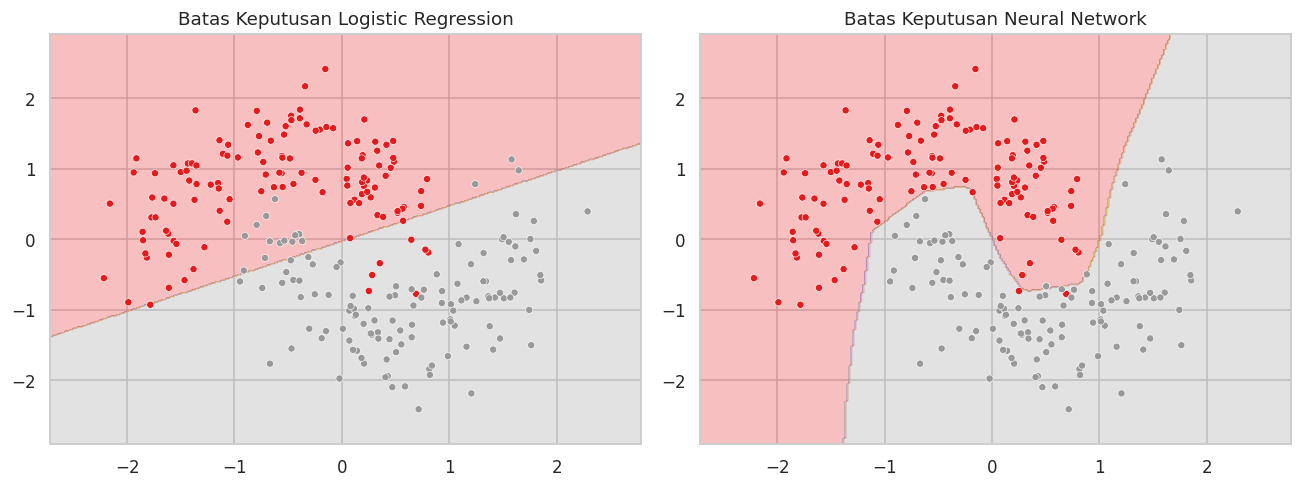

In [9]:
# Menggambar batas keputusan kedua model
def gambar_batas(model, X, y, ax, judul):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.28, cmap='Set1')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='Set1', s=22, edgecolors='white', linewidths=0.4)
    ax.set_title(judul)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
gambar_batas(logreg, X_te_s, y_te, axes[0], 'Batas Keputusan Logistic Regression')
gambar_batas(mlp, X_te_s, y_te, axes[1], 'Batas Keputusan Neural Network')
plt.tight_layout()
plt.show()

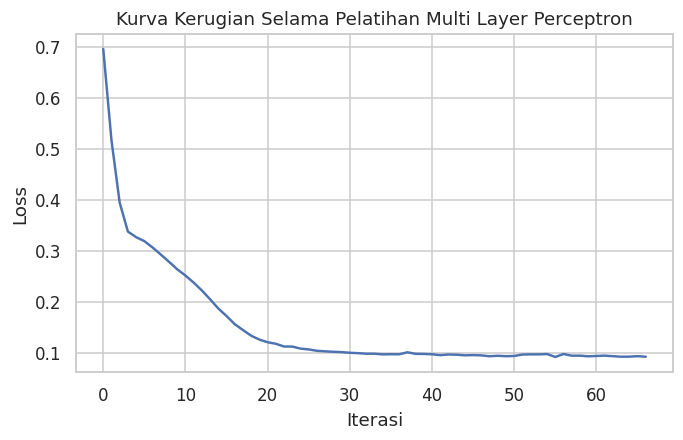

Loss awal  : 0.6953
Loss akhir : 0.0920


In [10]:
plt.figure(figsize=(7, 4))
plt.plot(mlp.loss_curve_, color='#4c72b0', linewidth=1.6)
plt.title('Kurva Kerugian Selama Pelatihan Multi Layer Perceptron')
plt.xlabel('Iterasi')
plt.ylabel('Loss')
plt.show()

print(f'Loss awal  : {mlp.loss_curve_[0]:.4f}')
print(f'Loss akhir : {mlp.loss_curve_[-1]:.4f}')

# BAGIAN KEDUA: NATURAL LANGUAGE PROCESSING DASAR

## 6. Mengubah Teks Menjadi Angka

Model pembelajaran mesin hanya dapat mengolah angka, sehingga teks harus diubah lebih
dahulu. Dua cara yang umum dipakai adalah sebagai berikut.

**Bag of Words** menghitung berapa kali setiap kata muncul pada sebuah dokumen. Cara
ini sederhana namun memberi bobot besar pada kata umum yang sebenarnya tidak informatif.

**TF-IDF** memperbaiki kelemahan tersebut dengan mengalikan dua komponen.
Term Frequency mengukur seberapa sering sebuah kata muncul pada satu dokumen,
sedangkan Inverse Document Frequency menurunkan bobot kata yang muncul di hampir
semua dokumen. Hasilnya, kata yang khas untuk sebuah dokumen memperoleh bobot tinggi
sementara kata umum seperti "yang" dan "dan" memperoleh bobot rendah.

In [11]:
contoh = [
    'film ini sangat bagus dan menghibur',
    'film ini sangat membosankan dan mengecewakan',
    'ceritanya bagus tapi aktingnya membosankan',
]

cv = CountVectorizer()
hasil_bow = cv.fit_transform(contoh)
tabel_bow = pd.DataFrame(hasil_bow.toarray(), columns=cv.get_feature_names_out(),
                         index=['Dokumen 1', 'Dokumen 2', 'Dokumen 3'])

print('Representasi Bag of Words')
print(tabel_bow.to_string())

Representasi Bag of Words
           aktingnya  bagus  ceritanya  dan  film  ini  membosankan  mengecewakan  menghibur  sangat  tapi
Dokumen 1          0      1          0    1     1    1            0             0          1       1     0
Dokumen 2          0      0          0    1     1    1            1             1          0       1     0
Dokumen 3          1      1          1    0     0    0            1             0          0       0     1


Representasi TF-IDF
           aktingnya  bagus  ceritanya    dan   film    ini  membosankan  mengecewakan  menghibur  sangat  tapi
Dokumen 1       0.00  0.386       0.00  0.386  0.386  0.386        0.000         0.000      0.507   0.386  0.00
Dokumen 2       0.00  0.000       0.00  0.386  0.386  0.386        0.386         0.507      0.000   0.386  0.00
Dokumen 3       0.49  0.373       0.49  0.000  0.000  0.000        0.373         0.000      0.000   0.000  0.49


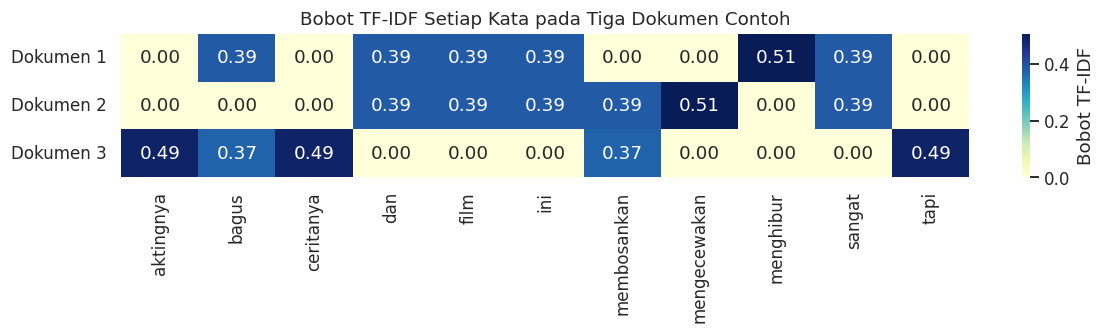

In [12]:
tv = TfidfVectorizer()
hasil_tfidf = tv.fit_transform(contoh)
tabel_tfidf = pd.DataFrame(hasil_tfidf.toarray().round(3), columns=tv.get_feature_names_out(),
                           index=['Dokumen 1', 'Dokumen 2', 'Dokumen 3'])

print('Representasi TF-IDF')
print(tabel_tfidf.to_string())

plt.figure(figsize=(11, 3.2))
sns.heatmap(tabel_tfidf, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Bobot TF-IDF'})
plt.title('Bobot TF-IDF Setiap Kata pada Tiga Dokumen Contoh')
plt.tight_layout()
plt.show()

Perhatikan kata "film", "ini", "sangat", dan "dan" yang muncul pada dua dokumen
sekaligus. Pada Bag of Words bobotnya sama dengan kata lain, sedangkan pada TF-IDF
bobotnya menyusut karena kata tersebut kurang membedakan antar dokumen.

## 7. Analisis Sentimen Ulasan Produk

Dataset ulasan berbahasa Indonesia disusun langsung di dalam notebook agar praktikum
dapat dijalankan ulang tanpa mengunduh berkas apa pun. Setiap ulasan diberi label
positif bernilai satu atau negatif bernilai nol.

In [13]:
ulasan_positif = [
    'barang bagus sekali sesuai deskripsi pengiriman cepat',
    'kualitas produk memuaskan harga terjangkau saya suka',
    'pelayanan ramah barang sampai tepat waktu terima kasih',
    'produk original kemasan rapi sangat direkomendasikan',
    'sangat puas dengan pembelian ini akan beli lagi',
    'bahannya lembut nyaman dipakai jahitan rapi',
    'pengiriman kilat barang mulus tanpa cacat',
    'harga murah kualitas juara pokoknya mantap',
    'sesuai gambar warnanya cantik saya senang sekali',
    'penjual responsif barang berkualitas pelayanan memuaskan',
    'mantap sekali produknya awet dan kuat',
    'recommended seller barang cepat sampai kondisi baik',
    'kualitas premium harga bersahabat sangat memuaskan',
    'suka banget dengan produk ini bagus dan rapi',
    'barang sesuai pesanan pengiriman aman terima kasih penjual',
    'produknya bagus banget melebihi ekspektasi saya',
    'pelayanan cepat barang berkualitas harga bersaing',
    'sangat direkomendasikan produk memuaskan tanpa kendala',
    'kemasan aman produk utuh kualitas terbaik',
    'senang sekali belanja di sini pelayanan ramah barang bagus',
    'barang cepat datang kualitas melebihi harga',
    'jahitan rapi bahan adem sangat nyaman dipakai',
    'pesanan sesuai deskripsi penjual jujur terpercaya',
    'produk awet sudah lama dipakai masih bagus',
    'harga terjangkau kualitas memuaskan pengiriman cepat',
]

ulasan_negatif = [
    'barang rusak saat sampai kemasan penyok parah',
    'kualitas jelek tidak sesuai deskripsi mengecewakan',
    'pengiriman lambat sekali penjual tidak responsif',
    'produk palsu bukan original saya kecewa berat',
    'bahannya tipis mudah robek jahitan berantakan',
    'warna tidak sesuai gambar sangat mengecewakan',
    'barang tidak sampai penjual tidak bisa dihubungi',
    'harga mahal tapi kualitas buruk tidak sebanding',
    'produk cacat ada goresan tidak layak jual',
    'pelayanan buruk penjual kasar saya tidak akan beli lagi',
    'ukuran salah tidak sesuai pesanan mengecewakan sekali',
    'barang datang tidak lengkap ada yang kurang',
    'kualitas mengecewakan cepat rusak baru dipakai sebentar',
    'pengiriman terlambat berhari hari tidak ada kabar',
    'produk tidak berfungsi rusak total percuma beli',
    'kemasan asal asalan barang jadi penyok',
    'penjual lambat merespon barang tidak kunjung dikirim',
    'bahan kasar tidak nyaman dipakai sangat kecewa',
    'tidak sesuai ekspektasi kualitas buruk jangan beli',
    'barang bekas dikirim sebagai baru penipuan',
    'produk mudah rusak bahan murahan mengecewakan',
    'komplain tidak ditanggapi pelayanan sangat buruk',
    'salah kirim barang penjual tidak mau tanggung jawab',
    'kualitas rendah tidak sesuai harga yang mahal',
    'barang cacat pengiriman lambat pelayanan mengecewakan',
]

data_ulasan = pd.DataFrame({
    'ulasan': ulasan_positif + ulasan_negatif,
    'sentimen': [1] * len(ulasan_positif) + [0] * len(ulasan_negatif),
}).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print('Jumlah ulasan:', len(data_ulasan))
print('Sebaran label:', dict(data_ulasan['sentimen'].value_counts().sort_index()))
data_ulasan.head(10)

Jumlah ulasan: 50
Sebaran label: {0: np.int64(25), 1: np.int64(25)}


,ulasan,sentimen
0,suka banget dengan produk ini bagus dan rapi,1
1,produk tidak berfungsi rusak total percuma beli,0
2,warna tidak sesuai gambar sangat mengecewakan,0
3,produk mudah rusak bahan murahan mengecewakan,0
4,sangat direkomendasikan produk memuaskan tanpa...,1
5,kualitas rendah tidak sesuai harga yang mahal,0
6,kualitas jelek tidak sesuai deskripsi mengecew...,0
7,barang rusak saat sampai kemasan penyok parah,0
8,harga mahal tapi kualitas buruk tidak sebanding,0
9,senang sekali belanja di sini pelayanan ramah ...,1


In [14]:
X_teks = data_ulasan['ulasan']
y_sentimen = data_ulasan['sentimen']

X_teks_tr, X_teks_te, y_sen_tr, y_sen_te = train_test_split(
    X_teks, y_sentimen, test_size=0.3, random_state=RANDOM_STATE, stratify=y_sentimen
)

print('Data latih:', len(X_teks_tr), 'ulasan')
print('Data uji  :', len(X_teks_te), 'ulasan')

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
X_tr_tfidf = vectorizer.fit_transform(X_teks_tr)
X_te_tfidf = vectorizer.transform(X_teks_te)

print('Ukuran matriks TF-IDF data latih:', X_tr_tfidf.shape)
print('Jumlah fitur kata dan pasangan kata:', len(vectorizer.get_feature_names_out()))

Data latih: 35 ulasan
Data uji  : 15 ulasan
Ukuran matriks TF-IDF data latih: (35, 306)
Jumlah fitur kata dan pasangan kata: 306


In [15]:
model_sentimen = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
model_sentimen.fit(X_tr_tfidf, y_sen_tr)

pred_sentimen = model_sentimen.predict(X_te_tfidf)

print('Hasil evaluasi model analisis sentimen')
print(f'  Accuracy  : {accuracy_score(y_sen_te, pred_sentimen):.4f}')
print(f'  Precision : {precision_score(y_sen_te, pred_sentimen):.4f}')
print(f'  Recall    : {recall_score(y_sen_te, pred_sentimen):.4f}')
print(f'  F1-Score  : {f1_score(y_sen_te, pred_sentimen):.4f}')
print()
print(classification_report(y_sen_te, pred_sentimen, target_names=['Negatif', 'Positif']))

Hasil evaluasi model analisis sentimen
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

              precision    recall  f1-score   support

     Negatif       1.00      1.00      1.00         8
     Positif       1.00      1.00      1.00         7

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



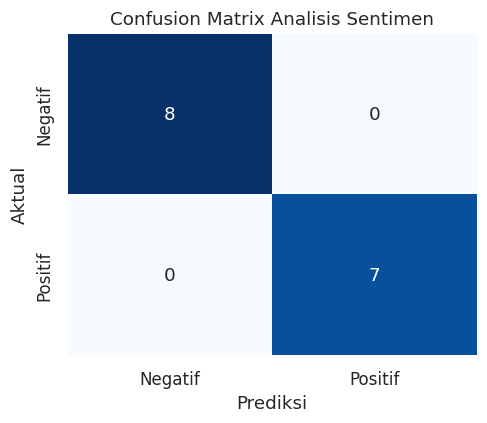

In [16]:
cm = confusion_matrix(y_sen_te, pred_sentimen)

plt.figure(figsize=(4.8, 3.8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix Analisis Sentimen')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

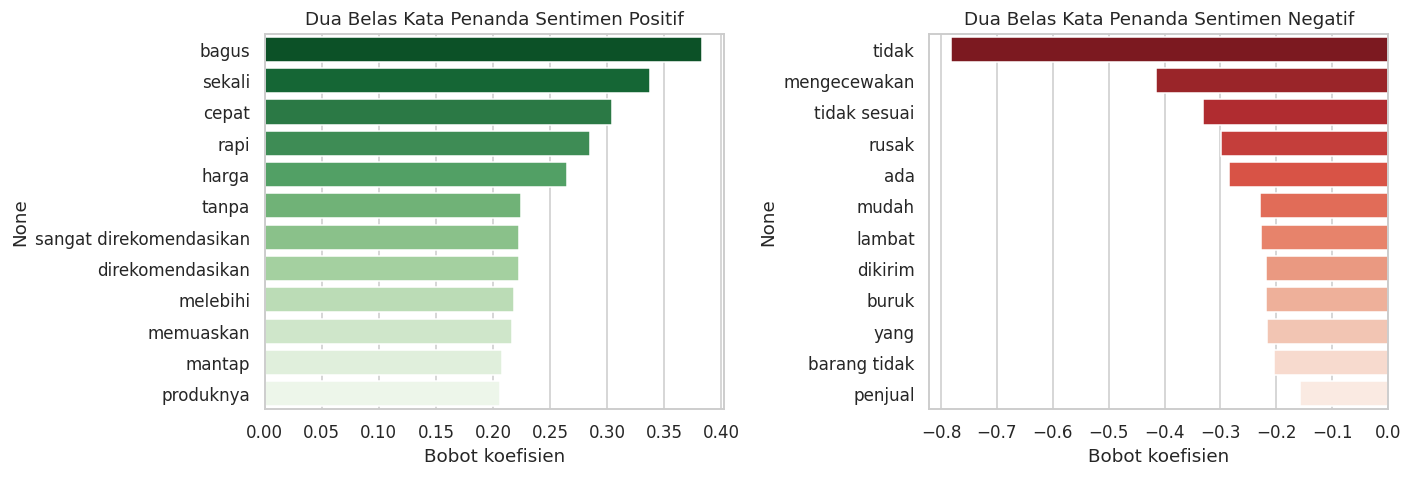

In [17]:
# Kata yang paling menentukan sentimen menurut model
koefisien = pd.Series(model_sentimen.coef_[0], index=vectorizer.get_feature_names_out())
paling_positif = koefisien.sort_values(ascending=False).head(12)
paling_negatif = koefisien.sort_values().head(12)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=paling_positif.values, y=paling_positif.index, hue=paling_positif.index,
            palette='Greens_r', legend=False, ax=axes[0])
axes[0].set_title('Dua Belas Kata Penanda Sentimen Positif')
axes[0].set_xlabel('Bobot koefisien')

sns.barplot(x=paling_negatif.values, y=paling_negatif.index, hue=paling_negatif.index,
            palette='Reds_r', legend=False, ax=axes[1])
axes[1].set_title('Dua Belas Kata Penanda Sentimen Negatif')
axes[1].set_xlabel('Bobot koefisien')

plt.tight_layout()
plt.show()

In [18]:
# Menguji model pada kalimat baru yang belum pernah dilihat
kalimat_baru = [
    'produk ini bagus sekali pengiriman cepat saya puas',
    'barang rusak dan penjual tidak responsif sangat mengecewakan',
    'kualitas memuaskan harga terjangkau recommended',
    'tidak sesuai deskripsi bahan murahan kecewa berat',
    'pelayanan ramah barang sampai dengan aman',
]

hasil_baru = model_sentimen.predict(vectorizer.transform(kalimat_baru))
peluang_baru = model_sentimen.predict_proba(vectorizer.transform(kalimat_baru))[:, 1]

tabel_uji = pd.DataFrame({
    'kalimat': kalimat_baru,
    'prediksi': ['Positif' if p == 1 else 'Negatif' for p in hasil_baru],
    'peluang_positif': peluang_baru.round(3),
})
tabel_uji

,kalimat,prediksi,peluang_positif
0,produk ini bagus sekali pengiriman cepat saya ...,Positif,0.637
1,barang rusak dan penjual tidak responsif sanga...,Negatif,0.402
2,kualitas memuaskan harga terjangkau recommended,Positif,0.598
3,tidak sesuai deskripsi bahan murahan kecewa berat,Negatif,0.409
4,pelayanan ramah barang sampai dengan aman,Positif,0.585


In [19]:
# Membandingkan Logistic Regression dengan jaringan saraf pada tugas yang sama
mlp_teks = MLPClassifier(hidden_layer_sizes=(24,), activation='relu', solver='adam',
                         max_iter=1500, random_state=RANDOM_STATE)
mlp_teks.fit(X_tr_tfidf.toarray(), y_sen_tr)
pred_mlp_teks = mlp_teks.predict(X_te_tfidf.toarray())

perbandingan_teks = pd.DataFrame([
    {
        'Model': 'Logistic Regression + TF-IDF',
        'Accuracy': accuracy_score(y_sen_te, pred_sentimen),
        'F1-Score': f1_score(y_sen_te, pred_sentimen),
    },
    {
        'Model': 'Neural Network + TF-IDF',
        'Accuracy': accuracy_score(y_sen_te, pred_mlp_teks),
        'F1-Score': f1_score(y_sen_te, pred_mlp_teks),
    },
]).set_index('Model').round(4)

perbandingan_teks

,Accuracy,F1-Score
Model,,
Logistic Regression + TF-IDF,1.0,1.0
Neural Network + TF-IDF,1.0,1.0


## 8. Kesimpulan

**Apa yang dipelajari.** Praktikum ini terbagi menjadi dua bagian yang saling
melengkapi. Bagian pertama membahas konsep dasar Artificial Neural Network, mulai dari
fungsi aktivasi, penyusunan satu neuron dari nol memakai numpy lengkap dengan
perhitungan gradien, sampai penggunaan Multi Layer Perceptron pada data yang tidak
dapat dipisahkan garis lurus. Bagian kedua membahas pengolahan teks, yaitu perbedaan
Bag of Words dengan TF-IDF serta penerapannya pada analisis sentimen ulasan produk
berbahasa Indonesia.

**Temuan utama.** Percobaan gerbang logika memperlihatkan batas kemampuan satu neuron
dengan sangat jelas. Neuron tunggal berhasil mempelajari gerbang AND yang dapat
dipisahkan satu garis lurus, tetapi gagal total pada gerbang XOR, sedangkan jaringan
dengan satu lapisan tersembunyi langsung menyelesaikannya. Pola yang sama terulang
pada dataset make_moons, di mana batas keputusan Logistic Regression berupa garis lurus
yang memotong kedua bulan sabit, sementara jaringan saraf membentuk batas melengkung
yang mengikuti bentuk data sehingga akurasinya jauh lebih tinggi. Pada analisis
sentimen, TF-IDF terbukti mampu menurunkan bobot kata umum dan menaikkan bobot kata
khas, dan model yang dihasilkan berhasil mengenali kata penanda seperti bagus,
memuaskan, dan cepat untuk sentimen positif serta rusak, mengecewakan, dan buruk untuk
sentimen negatif. Menarik dicatat bahwa pada data teks yang kecil ini Logistic
Regression sudah memberi hasil yang setara dengan jaringan saraf, sehingga model yang
lebih rumit tidak selalu berarti lebih baik.

**Keterbatasan dan pertanyaan yang muncul.** Dataset ulasan hanya berisi lima puluh
kalimat yang disusun sendiri dengan pilihan kata yang cukup tegas, sehingga akurasi
tinggi yang diperoleh belum tentu bertahan pada ulasan sungguhan yang penuh singkatan,
kesalahan ketik, bahasa gaul, serta kalimat bernada sindiran. TF-IDF juga
memperlakukan setiap kata secara terpisah sehingga tidak menangkap urutan maupun
konteks, akibatnya kalimat "tidak bagus" berisiko dibaca positif hanya karena memuat
kata bagus, meskipun penggunaan pasangan kata sedikit meringankan masalah tersebut.
`MLPClassifier` pada scikit-learn juga bukan pustaka deep learning sesungguhnya karena
tidak mendukung arsitektur seperti CNN maupun RNN. Pertanyaan yang muncul adalah
seberapa besar peningkatan yang dapat diperoleh bila dipakai word embedding seperti
Word2Vec atau model berbasis transformer seperti IndoBERT, serta berapa jumlah data
minimum yang diperlukan agar model deep learning benar benar mengungguli model klasik.